### Import das Classes

In [1]:
import matplotlib.pyplot as plt

from src.ProblemaP1 import ProblemaP1
from src.ProblemaP2 import ProblemaP2


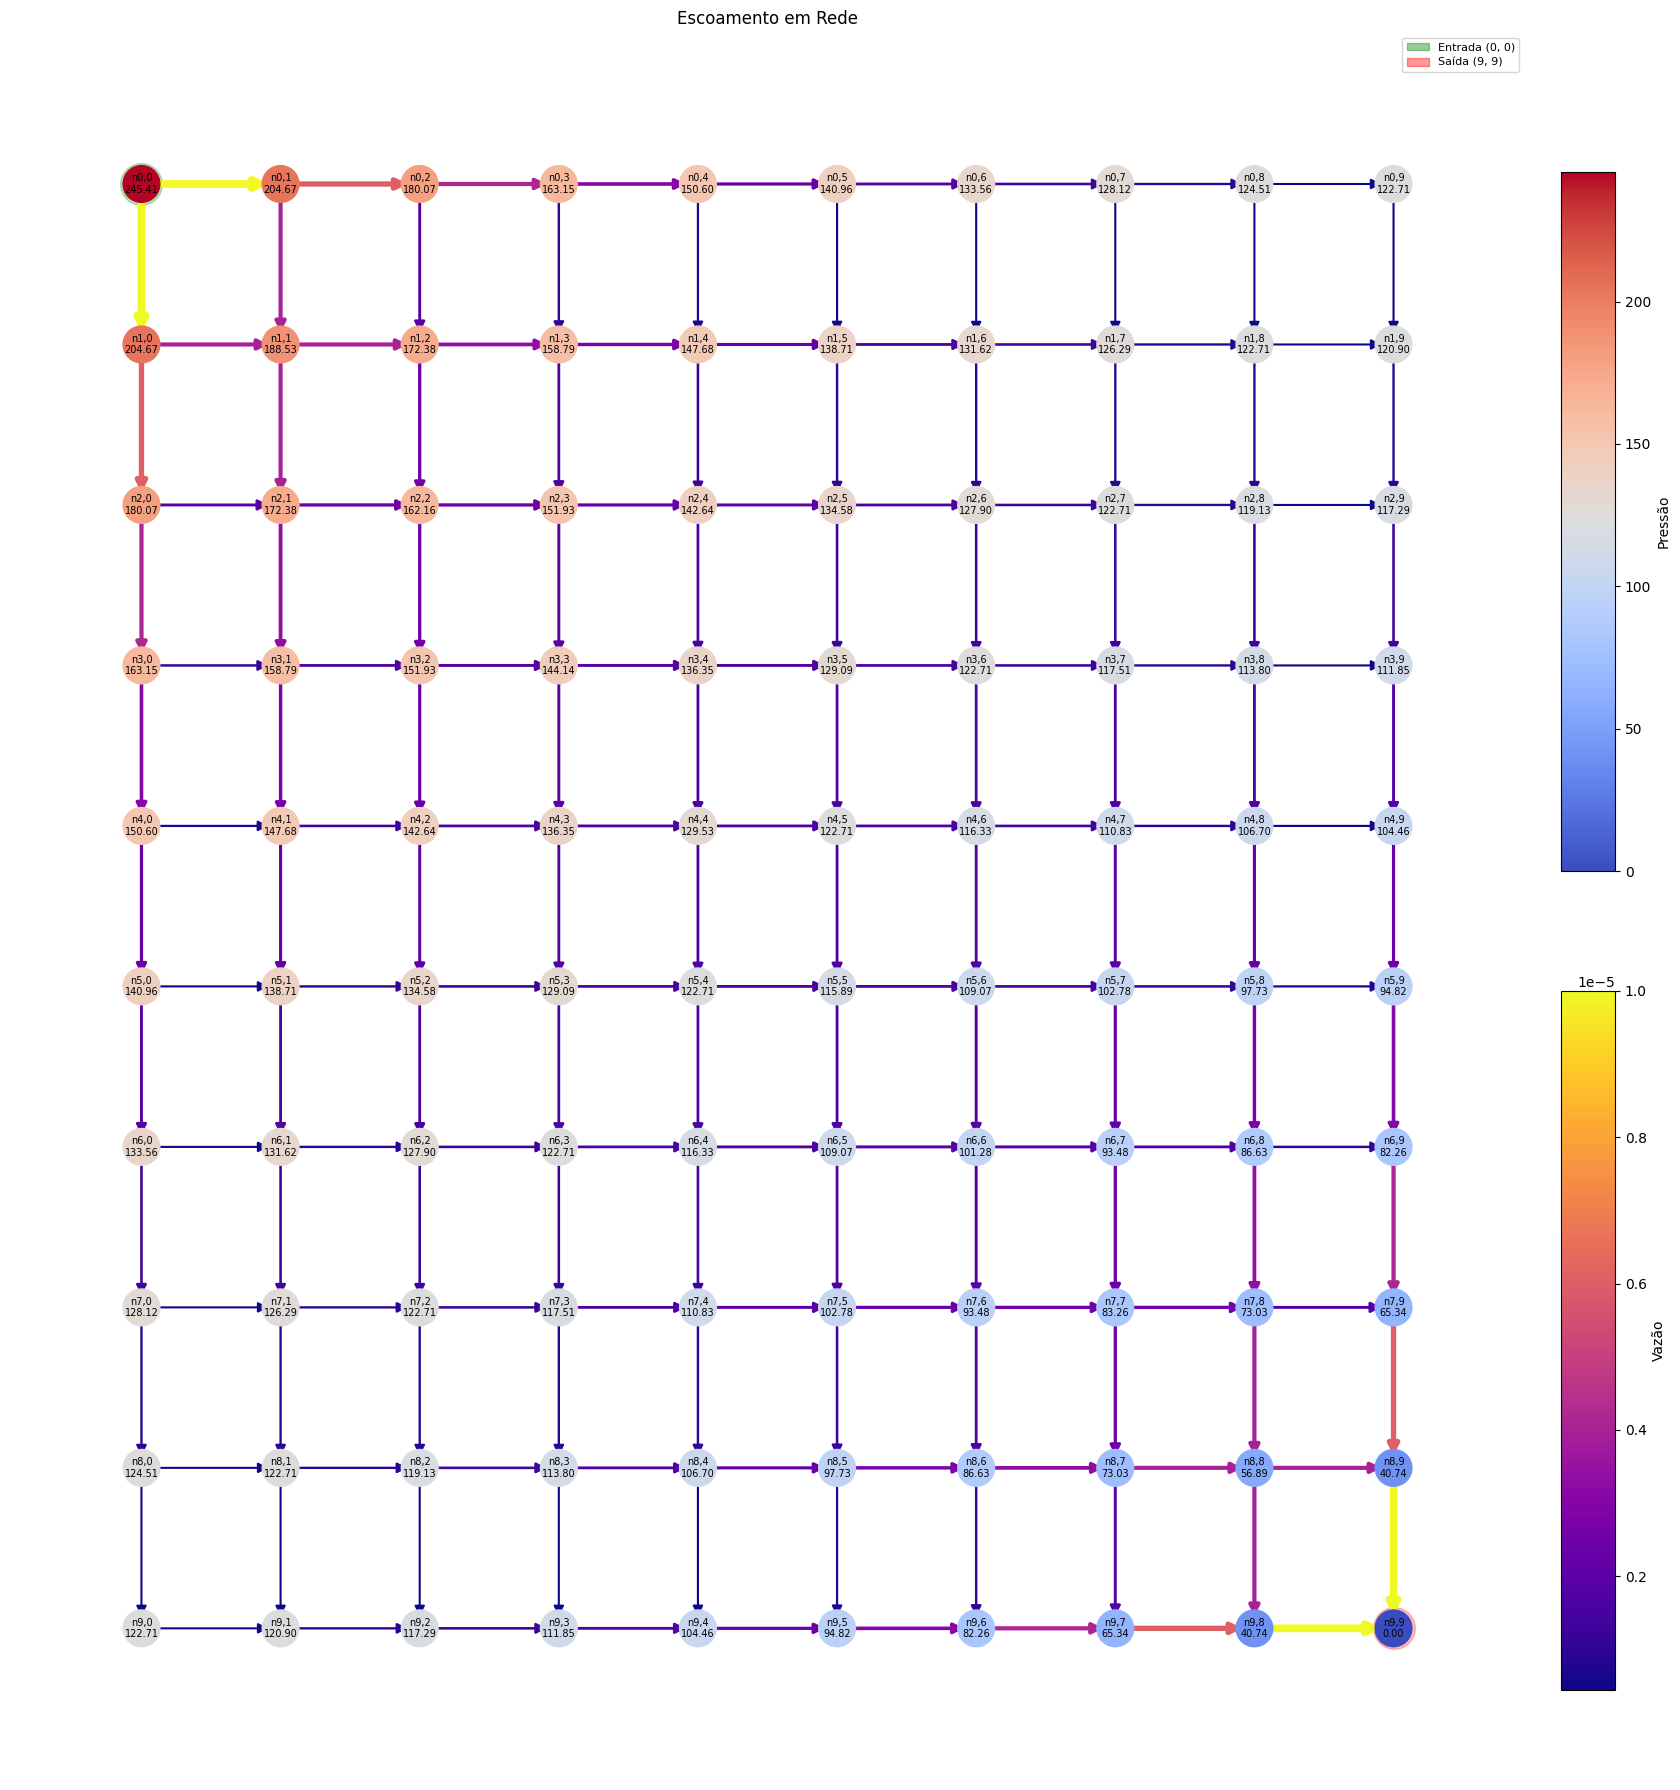

In [2]:
from src.Exemplos import set_grid_p1

p1 = set_grid_p1(10)
p1.setup().solve()
p1.plot_grid()

Pressão Nominal: 245.41 Pa | Limite P_max: 319.04 Pa

n_samples  | r_prob     | P_f_hat    | Std_Between  | IC 95%              
-----------------------------------------------------------------
10         | 0.020      | 0.01000    | 0.03051      | [0.00000, 0.02092]
10         | 0.050      | 0.08333    | 0.09499      | [0.04934, 0.11732]
10         | 0.080      | 0.26333    | 0.14016      | [0.21318, 0.31349]
10         | 0.100      | 0.38667    | 0.15253      | [0.33209, 0.44125]
10         | 0.120      | 0.49333    | 0.15522      | [0.43779, 0.54888]
10         | 0.150      | 0.62667    | 0.15071      | [0.57274, 0.68060]
10         | 0.200      | 0.88333    | 0.09855      | [0.84807, 0.91860]
10         | 0.250      | 0.97667    | 0.05040      | [0.95863, 0.99470]
-----------------------------------------------------------------
50         | 0.020      | 0.00733    | 0.01112      | [0.00335, 0.01131]
50         | 0.050      | 0.07467    | 0.03928      | [0.06061, 0.08872]
50       

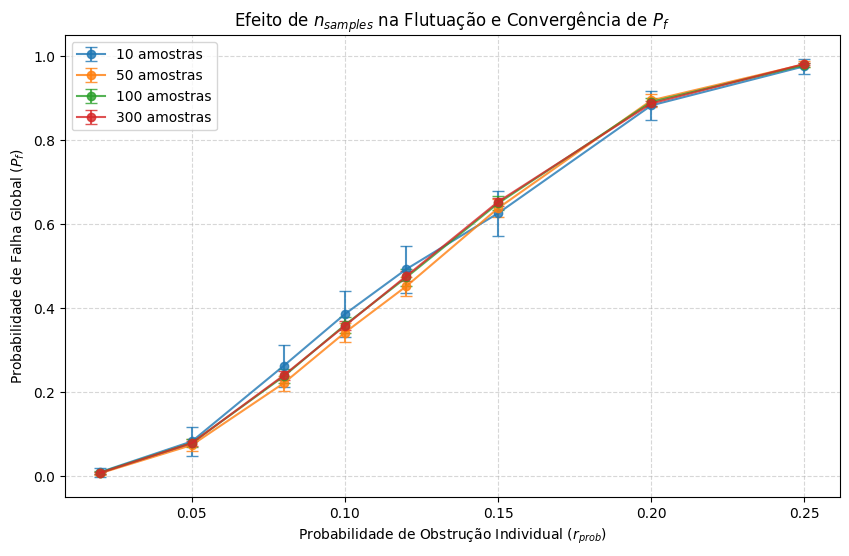

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from src.Exemplos import set_grid_p1
from src.ProblemaP2 import ProblemaP2

# 1. Inicializa o grid base
p1 = set_grid_p1(10).setup()
p_max_nominal = p1.solve().max()

# Definimos uma margem de segurança folgada (30% acima do normal)
P_max = p_max_nominal * 1.30  

# Probabilidades para a varredura
probabilidades_teste = [0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25]

# PREPARAÇÃO DO GRÁFICO: Criamos a figura ANTES do laço para colocar todas as linhas juntas
plt.figure(figsize=(10, 6))

print(f"Pressão Nominal: {p_max_nominal:.2f} Pa | Limite P_max: {P_max:.2f} Pa\n")
print(f"{'n_samples':<10} | {'r_prob':<10} | {'P_f_hat':<10} | {'Std_Between':<12} | {'IC 95%':<20}")
print("-" * 65)

# Testando diferentes tamanhos de amostra
for n_samples in [10, 50, 100, 300]:  
    # IMPORTANTE: Resetamos as listas para cada novo tamanho de amostra
    resultados_pf = []
    erros_ic = []
    
    for r in probabilidades_teste:
        p2 = ProblemaP2(
            p1_instance=p1, 
            alpha=15.0,       # Obstrução pesada
            r_prob=r, 
            P_max=P_max, 
            n_problems=30, 
            n_samples=n_samples, 
            seed=42
        )
        
        p2.run()
        summary = p2.summary()
        
        pf = summary['P_f_hat']
        std_b = summary['std_between']
        ic = summary['IC_95%']
        
        resultados_pf.append(pf)
        erros_ic.append((ic[1] - ic[0]) / 2)
        
        print(f"{n_samples:<10} | {r:<10.3f} | {pf:<10.5f} | {std_b:<12.5f} | [{ic[0]:.5f}, {ic[1]:.5f}]")
    
    print("-" * 65)
    
    # Plota a linha deste n_samples específico (repare o f'' corrigido no label)
    plt.errorbar(
        probabilidades_teste, 
        resultados_pf, 
        yerr=erros_ic, 
        fmt='-o', 
        capsize=4, 
        alpha=0.8, 
        label=f'{n_samples} amostras'
    )

# CONFIGURAÇÕES FINAIS DO GRÁFICO (Fora dos laços)
plt.title('Efeito de $n_{samples}$ na Flutuação e Convergência de $P_f$')
plt.xlabel('Probabilidade de Obstrução Individual ($r_{prob}$)')
plt.ylabel('Probabilidade de Falha Global ($P_f$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper left')
plt.show()

In [20]:
import math

def calcular_reynolds(vazao_q, diametro_d, densidade_rho=1000.0, viscosidade_mu=1e-3):
    """
    Calcula o número de Reynolds para escoamento interno em tubos circulares.
    """
    reynolds = (4 * densidade_rho * vazao_q) / (math.pi * viscosidade_mu * diametro_d)
    return reynolds

# 1. Definindo os parâmetros físicos e geométricos (segundo seu texto)
D = 1e-2         # Diâmetro interno = 10^-2 m
rho = 1e3        # Densidade da água = 10^3 kg/m^3
mu = 1e-3        # Viscosidade dinâmica = 10^-3 Pa.s
Q_in = 2e-5      # Vazão de entrada = 2.0 * 10^-5 m^3/s

# 2. Calculando a vazão no trecho mais crítico (metade da entrada)
Q_tubo = Q_in / 2 

# 3. Executando o cálculo
Re = calcular_reynolds(vazao_q=Q_tubo, diametro_d=D, densidade_rho=rho, viscosidade_mu=mu)

print(f"Número de Reynolds: {Re:.2f}")

# 4. Classificação automática do regime
if Re < 2300:
    print("Classificação: Escoamento Laminar")
elif 2300 <= Re <= 4000:
    print("Classificação: Escoamento de Transição")
else:
    print("Classificação: Escoamento Turbulento")

Número de Reynolds: 1273.24
Classificação: Escoamento Laminar


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from src.Exemplos import set_grid_p1
from src.ProblemaP2 import ProblemaP2

# 1. Inicializa o grid base
p1 = set_grid_p1(10).setup()
# p1.inflow_pressure = 9806  # Pressão de entrada em Pa
p_max_nominal = p1.solve().max()

# Definimos uma margem de segurança folgada (30% acima do normal)
P_max = p_max_nominal * 0.30  

Q_ext = p1.Q_ext.copy() 

# Identificar quem são os nós zerados e qual é o total de vazão negativa
nos_zerados = [k for k, v in Q_ext.items() if v == 0.0]
nos_negativos = [k for k, v in Q_ext.items() if v < 0.0]
total_negativo = sum(Q_ext[k] for k in nos_negativos)

# Redistribuir se houver nós zerados
if nos_zerados:
    vazao_fracionada = total_negativo / len(nos_zerados)
    
    # Zera os nós que originalmente eram a saída (n9,9)
    for k in nos_negativos:
        Q_ext[k] = 0.0
        
    # Aplica a fração da vazão negativa nos nós que estavam zerados
    for k in nos_zerados:
        Q_ext[k] = vazao_fracionada

# Verificação de segurança (Conservação de Massa)
soma_total = sum(Q_ext.values())
p1.set_Q_ext(Q_ext)

# # Probabilidades para a varredura
probabilidades_teste = np.linspace(0.01, 0.3, 50)  

# # PREPARAÇÃO DO GRÁFICO: Criamos a figura ANTES do laço para colocar todas as linhas juntas
plt.figure(figsize=(10, 6))

print(f"Pressão Nominal: {p_max_nominal:.2f} Pa | Limite P_max: {P_max:.2f} Pa\n")
print(f"{'n_samples':<10} | {'r_prob':<10} | {'P_f_hat':<10} | {'Std_Between':<12} | {'IC 95%':<20}")
print("-" * 65)

# # Testando diferentes tamanhos de amostra
for n_samples in [100]:  
#     # IMPORTANTE: Resetamos as listas para cada novo tamanho de amostra
    resultados_pf = []
    erros_ic = []
    
    for r in probabilidades_teste:
        p2 = ProblemaP2(
            p1_instance=p1, 
            alpha=15.0,       # Obstrução pesada
            r_prob=r, 
            P_max=P_max, 
            n_problems=30, 
            n_samples=n_samples, 
            seed=42
        )
        
        p2.run()
        summary = p2.summary()
        
        pf = summary['P_f_hat']
        std_b = summary['std_between']
        ic = summary['IC_95%']
        
        resultados_pf.append(pf)
        erros_ic.append((ic[1] - ic[0]) / 2)
        
        print(f"{n_samples:<10} | {r:<10.4f} | {pf:<10.4f} | {std_b:<12.4f} | [{ic[0]:.4f}, {ic[1]:.4f}]")
    
    print("-" * 65)
    
    # Plota a linha deste n_samples específico (repare o f'' corrigido no label)
    plt.errorbar(
        probabilidades_teste, 
        resultados_pf, 
        yerr=erros_ic, 
        fmt='-o', 
        capsize=4, 
        alpha=0.8, 
        label=f'{n_samples} amostras'
    )

# # CONFIGURAÇÕES FINAIS DO GRÁFICO (Fora dos laços)
plt.title('Efeito de $n_{samples}$ na Flutuação e Convergência de $P_f$')
plt.xlabel('$r_{prob}$')
plt.ylabel('$P_f$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper left')
plt.show()

Pressão Nominal: 245.41 Pa | Limite P_max: 73.62 Pa

n_samples  | r_prob     | P_f_hat    | Std_Between  | IC 95%              
-----------------------------------------------------------------
100        | 0.0100     | 0.0197     | 0.0145       | [0.0145, 0.0249]
100        | 0.0159     | 0.0287     | 0.0159       | [0.0230, 0.0344]


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

a = 28.499666
b = 0.127854


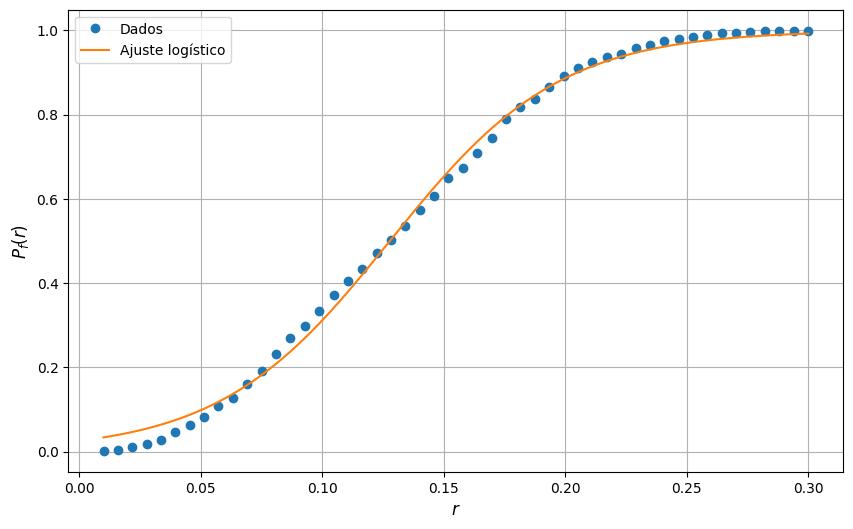


Função ajustada:

P_f(r) = 1 / (1 + exp(-28.499666(r - 0.127854)))


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Dados
# ============================================================

r = np.array([
    0.0100, 0.0159, 0.0218, 0.0278, 0.0337,
    0.0396, 0.0455, 0.0514, 0.0573, 0.0633,
    0.0692, 0.0751, 0.0810, 0.0869, 0.0929,
    0.0988, 0.1047, 0.1106, 0.1165, 0.1224,
    0.1284, 0.1343, 0.1402, 0.1461, 0.1520,
    0.1580, 0.1639, 0.1698, 0.1757, 0.1816,
    0.1876, 0.1935, 0.1994, 0.2053, 0.2112,
    0.2171, 0.2231, 0.2290, 0.2349, 0.2408,
    0.2467, 0.2527, 0.2586, 0.2645, 0.2704,
    0.2763, 0.2822, 0.2882, 0.2941, 0.3000
])

pf = np.array([
    0.0020, 0.0047, 0.0107, 0.0187, 0.0280,
    0.0467, 0.0620, 0.0827, 0.1080, 0.1273,
    0.1607, 0.1920, 0.2307, 0.2687, 0.2973,
    0.3340, 0.3727, 0.4047, 0.4333, 0.4713,
    0.5033, 0.5367, 0.5727, 0.6080, 0.6487,
    0.6733, 0.7080, 0.7453, 0.7887, 0.8173,
    0.8367, 0.8653, 0.8927, 0.9100, 0.9253,
    0.9380, 0.9447, 0.9580, 0.9653, 0.9740,
    0.9800, 0.9840, 0.9900, 0.9933, 0.9940,
    0.9967, 0.9987, 0.9987, 0.9993, 0.9993
])

# ============================================================
# Função logística
# ============================================================

def logistic(r, a, b):
    return 1 / (1 + np.exp(-a * (r - b)))

# ============================================================
# Ajuste dos parâmetros
# ============================================================

params, covariance = curve_fit(
    logistic,
    r,
    pf,
    p0=[40, 0.13]   # chute inicial
)

a_fit, b_fit = params

print(f"a = {a_fit:.6f}")
print(f"b = {b_fit:.6f}")

# ============================================================
# Curva ajustada
# ============================================================

r_fino = np.linspace(r.min(), r.max(), 1000)
pf_fit = logistic(r_fino, a_fit, b_fit)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(r, pf, 'o', label='Dados')
plt.plot(r_fino, pf_fit, '-', label='Ajuste logístico')

plt.xlabel(r'$r$', fontsize=12)
plt.ylabel(r'$P_f(r)$',fontsize=12)

# plt.title('Ajuste Logístico da Probabilidade de Falha')

plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# Expressão final
# ============================================================

print("\nFunção ajustada:\n")
print(f"P_f(r) = 1 / (1 + exp(-{a_fit:.6f}(r - {b_fit:.6f})))")

In [40]:
import numpy as np
from scipy.optimize import root_scalar

# ============================================================
# Função logística ajustada
# ============================================================

a_fit = 28.499666
b_fit = 0.127854

def logistic(r):
    return 1 / (1 + np.exp(-a_fit * (r - b_fit)))

# ============================================================
# Função cuja raiz queremos encontrar
# h(r) = S(r) - y
# ============================================================

def h(r, y):
    return logistic(r) - y

# ============================================================
# Derivada de h(r)
# ============================================================

def dh(r, y):
    s = logistic(r)
    return a_fit * s * (1 - s)

# ============================================================
# Valor desejado
# ============================================================

y = 0.25

# ============================================================
# Busca da raiz pelo método de Newton
# ============================================================

sol = root_scalar(
    h,
    args=(y,),
    bracket=[0.0, 1],   # intervalo onde procuramos a raiz
    method='bisect'
)

# ============================================================
# Resultado
# ============================================================

if sol.converged:
    r_star = sol.root
    print("Raiz encontrada:")
    print(f"r* = {r_star:.6f}")
    print(f"S(r*) = {logistic(r_star):.6f}")
else:
    print("O método não convergiu.")

Raiz encontrada:
r* = 0.089306
S(r*) = 0.250000


In [56]:
import numpy as np
import pandas as pd

# ============================================================
# AJUSTE LOGÍSTICO FIXO
# ============================================================

# P_f(r) = 1 / (1 + exp(-a(r-b)))

a = 28.499666
b = 0.127854

# ============================================================
# TABELA DE FREQUÊNCIAS
# ============================================================

freq_table = {
    1: 0.25,
    2: 0.10,
    3: 0.06,
    4: 0.04,
    6: 0.03,
    8: 0.02,
    12: 0.01
}

# ============================================================
# VALORES DE y
# ============================================================

y_values = np.array([
    0.035,
    0.05,
    0.1,
    0.25,
    0.50,
    0.60,
    0.80,
    0.90,
    0.99
])

# ============================================================
# RESOLVE O PROBLEMA INVERSO
# ============================================================

rows = []

for y in y_values:

    # solução analítica da logística
    r_star = b - (1/a) * np.log((1-y)/y)

    # menor frequência admissível
    freq_escolhida = None

    for freq, r_lim in sorted(freq_table.items()):

        if r_lim <= r_star:
            freq_escolhida = freq
            break

    rows.append({
        "y": y,
        "r_star": round(r_star, 6),
        "frequencia_min": freq_escolhida
    })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

print(df)

# opcional
# df.to_csv("tabela_variando_y.csv", index=False)

       y    r_star  frequencia_min
0  0.035  0.011474              12
1  0.050  0.024539               8
2  0.100  0.050757               4
3  0.250  0.089306               3
4  0.500  0.127854               2
5  0.600  0.142081               2
6  0.800  0.176496               2
7  0.900  0.204951               2
8  0.990  0.289088               1


Varrendo o espaço de parâmetros 2D (Alpha vs R)...
--------------------------------------------------
Linha concluída: Alpha = 2.0 avaliado para todos os 'r'
Linha concluída: Alpha = 6.0 avaliado para todos os 'r'
Linha concluída: Alpha = 10.0 avaliado para todos os 'r'
Linha concluída: Alpha = 14.0 avaliado para todos os 'r'
Linha concluída: Alpha = 18.0 avaliado para todos os 'r'
Linha concluída: Alpha = 22.0 avaliado para todos os 'r'
Linha concluída: Alpha = 26.0 avaliado para todos os 'r'
Linha concluída: Alpha = 30.0 avaliado para todos os 'r'
--------------------------------------------------
Cálculo concluído! Renderizando o mapa de risco...


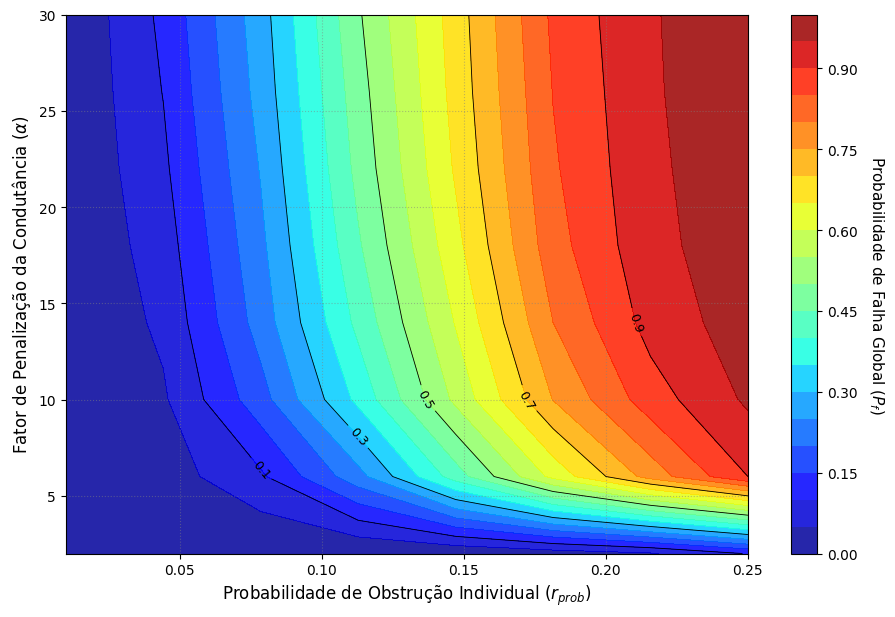

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from src.Exemplos import set_grid_p1
from src.ProblemaP2 import ProblemaP2

# 1. Inicializa o grid base e define o limite crítico P_max
p1 = set_grid_p1(10).setup()
p_max_nominal = p1.solve().max()
P_max = p_max_nominal * 1.30  # Margem de segurança de 30%

# 2. Configura os eixos do espaço de busca 2D (Malha 8x8)
# Reduzimos sutilmente a resolução da malha e das amostras para o loop rodar rápido
alphas = np.linspace(2.0, 30.0, 8)       # Eixo Y: severidade do gargalo
r_probs = np.linspace(0.01, 0.25, 8)     # Eixo X: chance de obstrução

# Matriz para armazenar as probabilidades de falha resultantes
Z_pf = np.zeros((len(alphas), len(r_probs)))

print("Varrendo o espaço de parâmetros 2D (Alpha vs R)...")
print("-" * 50)

# Preenche a matriz rodando o Monte Carlo para cada par (alpha, r)
for i, alpha in enumerate(alphas):
    for j, r in enumerate(r_probs):
        p2 = ProblemaP2(
            p1_instance=p1, 
            alpha=alpha, 
            r_prob=r, 
            P_max=P_max, 
            n_problems=10,    # Quantidade de experimentos por ponto
            n_samples=60,     # Amostras de Monte Carlo por experimento
            seed=42
        )
        p2.run()
        Z_pf[i, j] = p2.summary()['P_f_hat']
        
    print(f"Linha concluída: Alpha = {alpha:.1f} avaliado para todos os 'r'")

print("-" * 50)
print("Cálculo concluído! Renderizando o mapa de risco...")

# 3. Construção do Gráfico Bidimensional
plt.figure(figsize=(11, 7))

# Plota o mapa de calor contínuo (Contourf)
# O mapa 'coolwarm' ou 'jet' vai do azul (seguro/0%) ao vermelho (falha/100%)
mapeamento = plt.contourf(r_probs, alphas, Z_pf, levels=20, cmap='jet', alpha=0.85)

# Barra de cores lateral
cbar = plt.colorbar(mapeamento)
cbar.set_label('Probabilidade de Falha Global ($P_f$)', rotation=270, labelpad=20, fontsize=11)

# Adiciona linhas de contorno (isolinhas) pretas com os valores de probabilidade
linhas_contorno = plt.contour(r_probs, alphas, Z_pf, levels=[0.1, 0.3, 0.5, 0.7, 0.9], colors='black', linewidths=0.6)
plt.clabel(linhas_contorno, inline=True, fmt='%1.1f', fontsize=9, colors='black')

# Customização dos eixos e títulos
plt.title('', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Probabilidade de Obstrução Individual ($r_{prob}$)', fontsize=12)
plt.ylabel('Fator de Penalização da Condutância ($\\alpha$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5, color='gray')

plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from src.Exemplos import set_grid_p1
from src.ProblemaP2 import ProblemaP2

# 1. Inicializa o grid base e o limite crítico
p1 = set_grid_p1(10).setup()
p_max_nominal = p1.solve().max()
P_max = p_max_nominal * 1.30  

# Testando n_samples de 10 até 400 com passos de 15
amostras_teste = np.arange(10, 401, 15)
valores_pf = []
erros_padrao = []

print(f"Análise de convergência para r=0.15 (Limite P_max = {P_max:.2f} Pa)\n")
print(f"{'n_samples':<10} | {'P_f_hat':<10} | {'Erro Padrão (SE)':<18}")
print("-" * 45)

for n_samples in amostras_teste:
    p2 = ProblemaP2(
        p1_instance=p1, 
        alpha=15.0, 
        r_prob=0.15,      # Fixo conforme seu pedido
        P_max=P_max, 
        n_problems=15,    # Fixado para manter a mesma base de comparação
        n_samples=n_samples, 
        seed=42
    )
    p2.run()
    summary = p2.summary()
    
    valores_pf.append(summary['P_f_hat'])
    erros_padrao.append(summary['std_error'])
    
    print(f"{n_samples:<10} | {summary['P_f_hat']:<10.3f} | {summary['std_error']:<18.4f}")

# 2. Construção do Gráfico de Duplo Eixo (Gêmeo)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eixo 1: A convergência do valor de P_f
color = 'tab:blue'
ax1.set_xlabel('Número de Amostras ($n_{samples}$)', fontsize=12)
ax1.set_ylabel('Probabilidade de Falha ($P_f$)', color=color, fontsize=12)
ax1.plot(amostras_teste, valores_pf, '-o', color=color, linewidth=2, label='P_f Estimado')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Eixo 2: A queda do Erro Padrão (Incerteza)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Erro Padrão da Média (Incerteza)', color=color, fontsize=12)
ax2.plot(amostras_teste, erros_padrao, '--x', color=color, linewidth=1.5, label='Erro Padrão')
ax2.tick_params(axis='y', labelcolor=color)

# Linha guia de tolerância de 1% de erro absoluto
ax2.axhline(y=0.01, color='crimson', linestyle=':', label='Meta de Tolerância (1%)')

plt.title('Onde o Monte Carlo Converge para $r=0.15$?', fontsize=14, pad=15, fontweight='bold')
fig.tight_layout()
plt.show()

Análise de convergência para r=0.15 (Limite P_max = 319.04 Pa)

n_samples  | P_f_hat    | Erro Padrão (SE)  
---------------------------------------------
10         | 0.647      | 0.0376            
25         | 0.632      | 0.0196            
40         | 0.632      | 0.0212            
55         | 0.635      | 0.0158            
70         | 0.646      | 0.0143            
85         | 0.635      | 0.0128            
100        | 0.639      | 0.0097            
115        | 0.638      | 0.0092            
130        | 0.642      | 0.0077            
145        | 0.648      | 0.0090            
160        | 0.654      | 0.0086            
175        | 0.649      | 0.0106            
190        | 0.650      | 0.0083            
205        | 0.649      | 0.0092            
220        | 0.651      | 0.0085            
235        | 0.654      | 0.0066            
250        | 0.652      | 0.0075            
265        | 0.652      | 0.0070            
280        | 0.651      | 0.0063   

KeyboardInterrupt: 